# 07 · Varios flips: compensación, daño y detección

**Pregunta:** al repartir pesos, ¿los flips de signos opuestos conservan la lectura y reducen los cambios de banda que escapan al LSTM? ¿Qué ocurre cuando N crece?

Continuación de los experimentos 05 y 06. La unidad es **un mensaje atacado con N posiciones distintas**, observado después de todos los flips. Cada ataque se evalúa por separado: las demás lecturas del día se conservan. No son N mensajes ni una campaña simultánea contra toda la red.

Usamos las **predicciones y los p95 por estación ya guardados del notebook 09**. No entrenamos, recalibramos ni ejecutamos nueva inferencia. Este experimento no utiliza ±22 ppb como umbral común: el MAE y el umbral operativo son conceptos diferentes.

## 1. Qué cambia entre los formatos

La lectura legítima es idéntica antes del ataque y se conserva exactamente entre 0 y 255 ppb.

| Contribución original | Base | A | B |
|---|---|---|---|
| 8 | bit 3: 8 | bit 3: 8 | bit 3: 8 |
| 16 | bit 4: 16 | bits 4 y 8: 8 + 8 | bits 4 y 8: 8 + 8 |
| 32 | bit 5: 32 | bits 5 y 9: 16 + 16 | bits 5, 9, 10 y 11: 8 + 8 + 8 + 8 |

Los pesos 1, 2, 4, 64 y 128 se conservan. Los fragmentos de una misma contribución legítima comienzan todos encendidos o todos apagados; **no son bits independientes**. Tras un ataque se permiten combinaciones parciales y se suma su peso.

Evaluamos dos alcances:

1. **Grupo de siete bits de peso 8 de B:** posiciones 3, 4, 5, 8, 9, 10 y 11; N = 1…7. Es la prueba directa de la hipótesis de compensación. El 06 incluía seis; aquí agregamos el bit 3.
2. **Campo completo de 16 posiciones del valor:** N = 1…16, para Base, A y B. No incluye cabeceras, MIC ni otros campos de la trama. Las posiciones reservadas son 8…15 en Base, 10…15 en A y 12…15 en B. Activar una causa rechazo, contabilizado aparte.

Base es el control binario de dominio 0…255 del 05, no el formato firmado de 16 bits sin restricciones. El experimento estudia el payload modificado que llega al decodificador; no demuestra evasión de la autenticación de una trama LoRaWAN completa.

In [1]:
from pathlib import Path
import sys, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

actual=Path.cwd().resolve()
RAIZ=next(p for p in (actual,*actual.parents) if (p/'experiments/cayenne_mod/multiflip.py').is_file())
if str(RAIZ) not in sys.path:
    sys.path.insert(0,str(RAIZ))
from experiments.cayenne_mod import multiflip
from experiments.cayenne_mod.selectiva_red import codificar, decodificar
multiflip=importlib.reload(multiflip)
pd.set_option('display.max_columns',20)
pd.set_option('display.width',160)

## 2. La misma pareja puede cancelar o sumar daño

Apagar un bit de peso 8 resta 8; encenderlo suma 8. Para N flips en ese grupo:

$$\Delta = 8(n_{0\to1}-n_{1\to0}),\qquad n_{0\to1}+n_{1\to0}=N.$$

Con N impar no hay cancelación total dentro del grupo. Con N par es posible, pero depende de los estados originales. **Más bits de igual peso no garantizan que unos suban y otros bajen.**

In [2]:
filas=[]
for original,bits in [(28,(3,11)),(60,(3,11)),(60,(5,9,10,11)),(28,(5,9,10,11))]:
    p=codificar(original,'B')
    palabra=int.from_bytes(p[2:],'big')
    cambios=[8 if not ((palabra>>b)&1) else -8 for b in bits]
    mask=sum(1<<b for b in bits)
    recibido=decodificar(p[:2]+(palabra^mask).to_bytes(2,'big'),'B')
    filas.append(dict(original_ppb=original,bits=str(bits),cambios_ppb=str(cambios),
                      delta_ppb=sum(cambios),recibido_ppb=recibido))
display(pd.DataFrame(filas))

,original_ppb,bits,cambios_ppb,delta_ppb,recibido_ppb
0,28,"(3, 11)","[-8, 8]",0,28
1,60,"(3, 11)","[-8, -8]",-16,44
2,60,"(5, 9, 10, 11)","[-8, -8, -8, -8]",-32,28
3,28,"(5, 9, 10, 11)","[8, 8, 8, 8]",32,60


En 28 ppb, la pareja (3, 11) produce −8 + 8 = 0. En 60 ppb, ambos están encendidos y produce −16. En 60, los siete bits de peso 8 están encendidos: cualquier conjunto de N de ellos resta 8N.

Para 28 y dos flips existen 21 parejas: 12 cancelan, 6 suman 16 y 3 restan 16. Esta distribución cambia con la lectura. Invertir los cuatro fragmentos que reemplazan al bit 5 recupera su cambio original de ±32: repartir el peso no elimina esa posibilidad.

## 3. Cómo se calcula sin elegir una muestra favorable

Enumeramos **todas** las máscaras de N posiciones distintas: $\binom{7}{N}$ en el grupo y $\binom{16}{N}$ en el campo completo. Una máscara indica qué posiciones se invierten una vez. No se mezclan presupuestos ni se incluyen dos inversiones del mismo bit, que se desharían.

El promedio asigna igual probabilidad a cada máscara del mismo N. Es un modelo explícito de selección uniforme, **no una consecuencia de que el atacante vea texto cifrado**: un atacante puede conocer posiciones y elegir una máscara fija. Por eso también mostramos la peor máscara fija observada, elegida retrospectivamente entre las opciones de ese N.

Para cada mensaje se conserva su predicción, p95 y máximo diario competidor. Primero se calcula el efecto de cada par (original, recibido) en cada contexto; después se agrupan esos conteos y se consultan las máscaras. Es una enumeración exacta, sin promediar predicciones ni simular miles de millones de filas.

El caso N = 1 en las 16 posiciones debe reproducir exactamente el experimento 05. Se verifican las 65 535 máscaras no vacías sobre tres lecturas y tres formatos a través del flujo de cifrado del proyecto. El pipeline completo se ejecuta dos veces y se exige igualdad exacta antes de guardar.

In [3]:
n_cifrado=multiflip.validar_mascaras_cifradas()
test,anual,info=multiflip.construir(RAIZ)
test2,anual2,info2=multiflip.construir(RAIZ)
assert info==info2
for primero,segundo in [(test,test2),(anual,anual2)]:
    for nombre in primero:
        pd.testing.assert_frame_equal(primero[nombre],segundo[nombre],check_exact=True)
del test2,anual2
info['reproducibilidad']='Dos ejecuciones completas con tablas exactamente iguales'
info['verificaciones_cifrado']=n_cifrado
DESTINO=multiflip.guardar(RAIZ,test,anual,info)
print(f"Dos ejecuciones idénticas; {n_cifrado:,} transformaciones cifradas verificadas.")
print('Predicciones y p95 GUARDADOS del notebook 09; sin entrenamiento ni inferencia nueva.')
print(f"Test: {info['test_mensajes']:,} mensajes, {info['test_dias']} días; {info['test_periodo']}.")
print(f"Falsas alarmas limpias: {info['fpr_limpio_pct']:.2f}%. Máximo limpio en test: {info['test_maximo_ppb']:.0f} ppb.")
print(f"Análisis anual sin detector: {info['anual_mensajes']:,} lecturas en {info['anual_dias']} días.")
print(f"Resultados: {DESTINO.relative_to(RAIZ)}")

Dos ejecuciones idénticas; 589,815 transformaciones cifradas verificadas.
Predicciones y p95 GUARDADOS del notebook 09; sin entrenamiento ni inferencia nueva.
Test: 35,704 mensajes, 72 días; ['2025-10-21', '2025-12-31'].
Falsas alarmas limpias: 15.80%. Máximo limpio en test: 152 ppb.
Análisis anual sin detector: 218,823 lecturas en 365 días.
Resultados: experiments/cayenne_mod/resultados/07


## 4. Grupo B: ¿se cancela y qué sucede con la banda?

Cómo leer la siguiente tabla:

- **Valor intacto:** el payload cambia, pero la lectura decodificada queda igual. Una alerta en estos casos sería la misma alarma que tenía la lectura limpia; se excluye de la tasa de detección de valores alterados.
- **Cambian banda** y **cambian banda sin alerta:** número esperado de oportunidades entre los 35 704 mensajes si, al evaluar cada mensaje por separado, se elige una máscara uniforme de ese N. Pueden ser fraccionarios porque son promedios exactos. No son días ni el resultado de atacar todos los mensajes a la vez.
- **Alterados con alerta:** porcentaje detectado entre lecturas cuyo valor sí cambió, produzcan o no un cambio de banda.

La banda se calcula con el máximo diario de toda la red observado. Cambiar una lectura puede no cambiar ese máximo porque otra hora o estación lo sostiene.

In [4]:
t=test['resumen']
g=t.query("alcance == 'grupo_7x8'").copy()
cols={'n_flips':'N','pct_cancelacion_aceptados':'Valor intacto (%)',
      'delta_abs_medio_aceptados':'|Cambio| medio (ppb)',
      'cambio_banda_red_esperados':'Cambian banda (esperados)',
      'cambio_banda_red_escape_esperado':'Cambian banda sin alerta (esperados)',
      'recall_sobre_valores_cambiados_pct':'Alterados con alerta (%)'}
display(g[list(cols)].rename(columns=cols).round(3).reset_index(drop=True))
max_escape=g.loc[g.cambio_banda_red_escape_esperado.idxmax()]
display(Markdown(f"En este test, el mayor promedio de cambios de banda sin alerta dentro del grupo aparece con **N = {int(max_escape.n_flips)}**, con **{max_escape.cambio_banda_red_escape_esperado:.2f} oportunidades**. La cancelación de algunos ataques coexiste con el daño de otros."))

,N,Valor intacto (%),|Cambio| medio (ppb),Cambian banda (esperados),Cambian banda sin alerta (esperados),Alterados con alerta (%)
0,1,0.000,8.000,26.429,10.571,21.635
1,2,27.118,11.661,87.048,28.905,42.312
2,3,0.000,17.492,309.857,85.914,54.891
3,4,15.599,21.658,498.743,96.971,72.858
4,5,0.000,27.073,567.952,76.381,71.371
5,6,10.633,31.467,652.714,57.571,82.381
6,7,0.000,36.711,990.000,30.000,79.375


En este test, el mayor promedio de cambios de banda sin alerta dentro del grupo aparece con **N = 4**, con **96.97 oportunidades**. La cancelación de algunos ataques coexiste con el daño de otros.

## 5. Las 16 posiciones: comparar sin confundir rechazo con detección

Cada formato ofrece el mismo campo físico de 16 bits, pero distinta cantidad de bits activos. Para N flips, sólo $\binom{a}{N}$ máscaras se aceptan, con a = 8, 10 o 12. Las demás tocan posiciones reservadas.

Mostramos dos denominadores: **todos los intentos** y **sólo los aceptados**. El segundo permite observar el comportamiento cuando el atacante evita posiciones reservadas. Ninguno sustituye al otro. Una baja del riesgo entre todos los intentos puede deberse a más mensajes rechazados; eso implica pérdida de datos, cuyo efecto posterior no se modela aquí.

Cuando no hay mensajes aceptados, el riesgo condicionado a aceptación se deja vacío. No se presenta como una detección perfecta del LSTM.

In [5]:
campo=t.query("alcance == 'campo_16'").copy()
cols={'formato':'Formato','n_flips':'N','pct_rechazos':'Rechazados (%)',
      'cambio_banda_red_escape_pct_todos':'Banda sin alerta / todos (%)',
      'cambio_banda_red_escape_pct_aceptados':'Banda sin alerta / aceptados (%)',
      'peor_mascara_fija':'Peor máscara fija',
      'escapes_peor_mascara_fija':'Banda sin alerta con esa máscara'}
display(campo.loc[campo.n_flips.isin([1,2,3,4,7,12,16]),list(cols)]
        .sort_values(['n_flips','formato']).rename(columns=cols).round(4).reset_index(drop=True))
print('Tabla completa de N = 1…16: resultados/07/test_resumen.csv')
print('Peor máscara: misma máscara aplicada por separado a todos los mensajes; selección retrospectiva, no garantía futura.')

,Formato,N,Rechazados (%),Banda sin alerta / todos (%),Banda sin alerta / aceptados (%),Peor máscara fija,Banda sin alerta con esa máscara
0,A,1,37.5000,0.0383,0.0613,0x0040,106
1,B,1,25.0000,0.0324,0.0432,0x0040,106
2,base,1,50.0000,0.0714,0.1428,0x0020,228
3,A,2,62.5000,0.0504,0.1343,0x0220,228
4,B,2,45.0000,0.0445,0.0810,0x0050,127
5,base,2,76.6667,0.0482,0.2064,0x0050,223
6,A,3,78.5714,0.0389,0.1814,0x0150,223
7,B,3,60.7143,0.0563,0.1432,0x0150,223
8,base,3,90.0000,0.0223,0.2232,0x0054,226
9,A,4,88.4615,0.0229,0.1988,0x0154,226


Tabla completa de N = 1…16: resultados/07/test_resumen.csv
Peor máscara: misma máscara aplicada por separado a todos los mensajes; selección retrospectiva, no garantía futura.


## 6. Las gráficas del experimento

La primera figura responde a la compensación entre los siete bits. La segunda compara Base, A y B en el campo de 16 posiciones. La tercera contrasta el promedio uniforme con la peor máscara fija y mantiene separado el análisis anual sin LSTM.

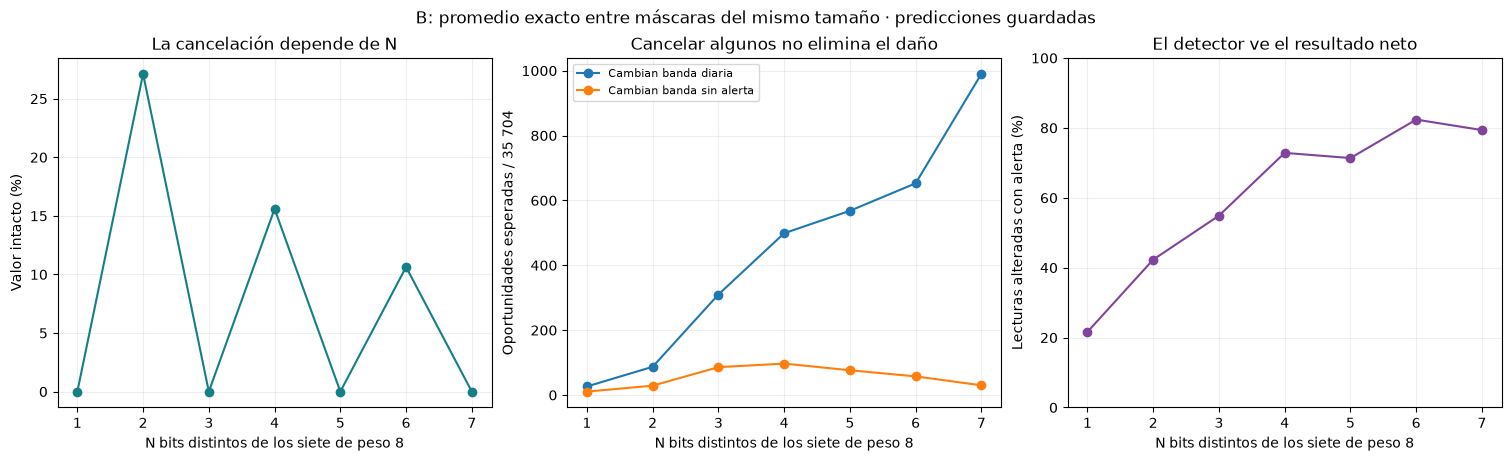

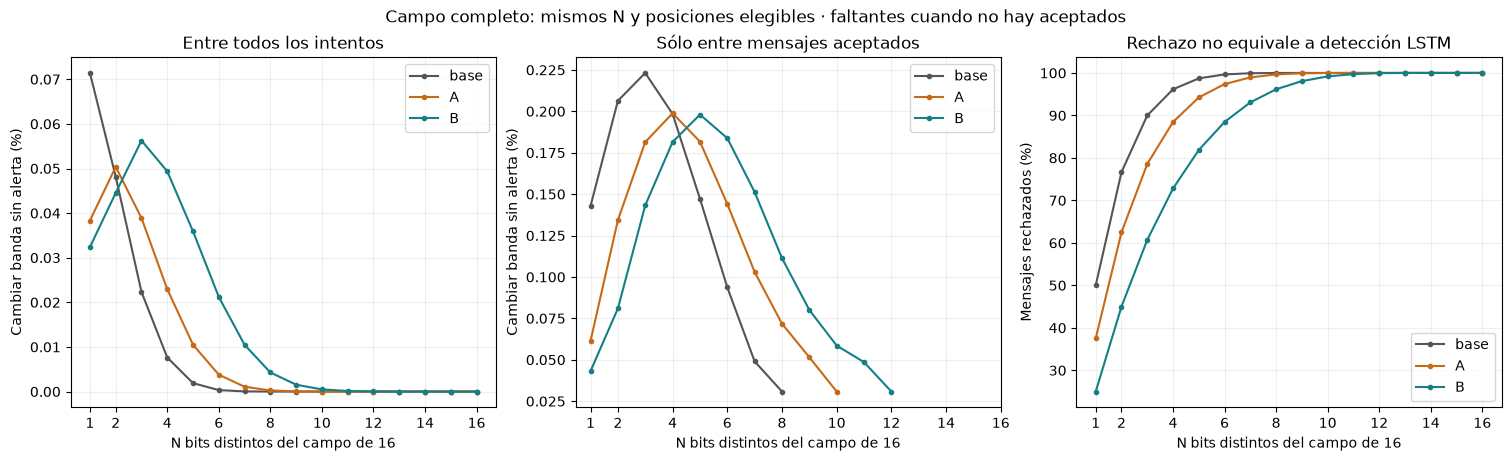

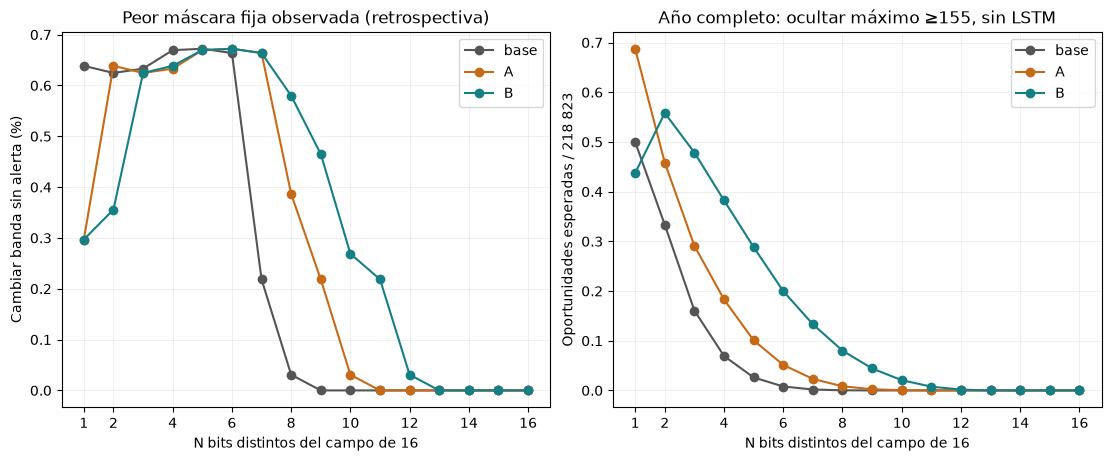

In [6]:
multiflip.graficar(test,anual,DESTINO)
plt.show()

## 7. Por qué un cambio grande no garantiza una alerta

El detector compara la lectura atacada con su predicción. Con predicción fija:

$$e_{ataque}=e_{limpio}+\Delta.$$

No compara solamente $|\Delta|$ con el umbral. El ataque puede alejar o acercar la lectura a la predicción. Incluso si el umbral fuera 22 ppb, tres cambios de +8 ya sumarían 24, pero la decisión todavía dependería del residuo previo; tampoco cuatro flips garantizan un cambio neto de 32.

La tabla siguiente muestra contraejemplos reales de esta evaluación. La máscara B indicada transforma la codificación legítima original en una representación del valor recibido; todos sus bits pertenecen al campo activo. Los ejemplos provienen del barrido exacto, no de nuevas predicciones.

In [7]:
ej=test['ejemplos_grandes_sin_alerta'].copy()
ej['mascara_B_hex']=ej.mascara_B.map(lambda m:f'0x{int(m):04X}')
display(ej[['timestamp','estacion','original','recibido','delta','predicho','umbral','residuo',
            'maximo_original','maximo_atacado','mascara_B_hex','n_flips_B']].head(2).round(3))
print('El máximo diario cambia de banda y el residuo atacado queda por debajo del p95.')
print('Estos ejemplos también muestran que un ataque puede reducir un residuo limpio ya alto.')

,timestamp,estacion,original,recibido,delta,predicho,umbral,residuo,maximo_original,maximo_atacado,mascara_B_hex,n_flips_B
0,2025-12-25 13:00:00,MER,92,33,-59,50.859,18.303,17.859,92.0,86.0,0x0F7D,10
1,2025-12-25 13:00:00,MER,92,34,-58,50.859,18.303,16.859,92.0,86.0,0x0F7E,10


El máximo diario cambia de banda y el residuo atacado queda por debajo del p95.
Estos ejemplos también muestran que un ataque puede reducir un residuo limpio ya alto.


## 8. Excedencia de 155 ppb: conservar la separación entre daño y detector

Una falsa excedencia y un cambio de banda no son la misma métrica. El test del LSTM no contiene máximos originales ≥155 ppb: sus ceros en ocultamiento no acreditan protección.

Por eso el ocultamiento se examina además sobre todo 2025, **sin extrapolar la detección** a ese año. Ese conjunto incluye el periodo de test; no es una validación temporal independiente.

In [8]:
display(Markdown('**Falsas excedencias en test: promedios uniformes sobre todas las máscaras**'))
display(campo.loc[campo.n_flips.isin([1,2,3,4,7]),
                  ['formato','n_flips','falsa_fase1_esperados','falsa_fase1_escape_esperado']]
        .sort_values(['n_flips','formato']).round(3).reset_index(drop=True))
display(Markdown('**Ocultamientos anuales sin LSTM: promedios uniformes sobre todas las máscaras**'))
a=anual['resumen'].query("alcance == 'campo_16'")
display(a.loc[a.n_flips.isin([1,2,3,4,7]),
              ['formato','n_flips','anulada_fase1_esperados','pct_rechazos']]
        .sort_values(['n_flips','formato']).round(3).reset_index(drop=True))
print(f"Año completo: {info['anual_dias_excedencia']} días con máximo observado ≥155 ppb.")

**Falsas excedencias en test: promedios uniformes sobre todas las máscaras**

,formato,n_flips,falsa_fase1_esperados,falsa_fase1_escape_esperado
0,A,1,895.250,0.125
1,B,1,894.125,0.000
2,base,1,897.125,0.062
3,A,2,1299.650,0.017
4,B,2,1544.600,0.167
5,base,2,1126.100,0.008
6,A,3,1370.462,0.061
7,B,3,1914.782,0.029
8,base,3,883.696,0.012
9,A,4,1183.429,0.021


**Ocultamientos anuales sin LSTM: promedios uniformes sobre todas las máscaras**

,formato,n_flips,anulada_fase1_esperados,pct_rechazos
0,A,1,0.688,37.500
1,B,1,0.438,25.000
2,base,1,0.500,50.000
3,A,2,0.458,62.500
4,B,2,0.558,45.000
5,base,2,0.333,76.667
6,A,3,0.291,78.571
7,B,3,0.479,60.714
8,base,3,0.161,90.000
9,A,4,0.183,88.462


Año completo: 6 días con máximo observado ≥155 ppb.


## 9. Resultados observados y límites

**La hipótesis de compensación se confirma como mecanismo; la mejora general no.**

- Entre los siete bits de peso 8, dos flips conservan la lectura en el **27.12 %** de los casos; cuatro en el **15.60 %** y seis en el **10.63 %**. Con N impar no hay cancelación total.
- El daño que escapa no disminuye de forma continua: pasa de **10.57 oportunidades esperadas con un flip** a **96.97 con cuatro**, y baja a **30 con siete**. Cada promedio corresponde a los mismos 35 704 mensajes evaluados por separado.
- En las 16 posiciones, con tres flips B tiene más cambios de banda sin alerta entre todos los intentos (**0.0563 %**) que la base (**0.0223 %**). Entre los aceptados B todavía tiene menor riesgo (**0.1432 % frente a 0.2232 %**); los distintos rechazos explican la inversión de la comparación. Con cinco flips B también tiene mayor riesgo entre los aceptados (**0.1980 % frente a 0.1472 %**).
- La máscara B **0x0E20**, que invierte los cuatro fragmentos del antiguo bit 5, recupera su cambio de ±32. Produce **228 oportunidades de cambio de banda sin alerta**, igual que invertir el bit 5 de la base con un solo flip. Repartir el peso aumenta el costo de reproducir ese ataque, pero no lo elimina.

### Alcance de la interpretación

- La compensación existe y depende del estado inicial, la máscara y N. No equivale a que todos los ataques de varios flips se mitiguen.
- Una inversión del payload que conserva la lectura no produce daño numérico en esta evaluación. Una inversión que cambia la lectura puede ser inocua para la banda diaria por la presencia de otras lecturas.
- La detección y el daño deben medirse conjuntamente. Una tasa mayor de alertas no basta si también crecen las oportunidades de cambiar banda sin alerta.
- Las posiciones reservadas generan rechazo, no detección por el LSTM. Falta evaluar el efecto operativo de perder lecturas y las campañas contra varios mensajes.
- Ver sólo texto cifrado no obliga al atacante a elegir uniformemente. La peor máscara fija muestra una sensibilidad a esa hipótesis, pero se seleccionó retrospectivamente sobre este conjunto.
- La decisión se evalúa inmediatamente, con predicciones y perfiles originales fijos. No se simula cómo un ataque podría contaminar entradas o predicciones futuras.
- Hace falta validar en otro periodo, especialmente con excedencias originales suficientes para evaluar su ocultamiento junto al detector.

**Conclusión para la tesis:** caracterizar para qué presupuestos y modelos de selección la distribución reduce el daño no detectado; no afirmar una protección general por el mero hecho de repartir el peso.

Los CSV guardan todos los presupuestos; `test_por_mascara.csv.gz` y `anual_por_mascara.csv.gz` contienen sólo máscaras aceptadas (las rechazadas están contabilizadas en los resúmenes). `*_deltas.csv` permite reconstruir las distribuciones del cambio neto. `protocolo.json` registra fuentes, hashes y comprobación de reproducibilidad.

[Resumen para la junta](avance_junta_07.md).